# Day 3 Assignment

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

## 1. Load and Prepare the Data

In [2]:
data = pd.read_csv('Cancer.csv')
data = data.drop(columns=['id', 'Unnamed: 32'])

# 将诊断结果转换为数值：B=0，M=1
data['diagnosis'] = data['diagnosis'].map({'B': 0, 'M': 1})

print(data.shape)
print(data.isnull().values.any())
print(data.diagnosis.value_counts())
data.head()

(569, 31)
False
diagnosis
0    357
1    212
Name: count, dtype: int64


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 2. Split the Training and Test Sets

In [3]:
target = 'diagnosis'
X = data.loc[:, data.columns != target]
y = data.loc[:, target]
features = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# PCA 和 LDA 对变量尺度敏感，因此只用训练集拟合标准化器
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

print('Training set:', X_train.shape)
print('Test set:', X_test.shape)

Training set: (398, 30)
Test set: (171, 30)


## 3. Logistic Regression Baseline with Original Features

In [4]:
logreg = LogisticRegression(C=0.01, max_iter=1000)
lr = logreg.fit(X_train_std, y_train)

baseline_pred = lr.predict(X_test_std)
print('LogReg Training set score:', lr.score(X_train_std, y_train))
print(' Test set score:', lr.score(X_test_std, y_test))
print(classification_report(y_test, baseline_pred))

LogReg Training set score: 0.9522613065326633
 Test set score: 0.9473684210526315
              precision    recall  f1-score   support

           0       0.92      1.00      0.96       107
           1       1.00      0.86      0.92        64

    accuracy                           0.95       171
   macro avg       0.96      0.93      0.94       171
weighted avg       0.95      0.95      0.95       171



## 4. Run PCA on the Cancer Dataset

Keep 90% of the cumulative variance, then check the number of features after dimensionality reduction.

Number of original features: 30
Number of PCA features: 7
Explained variance: 0.9116710228177686


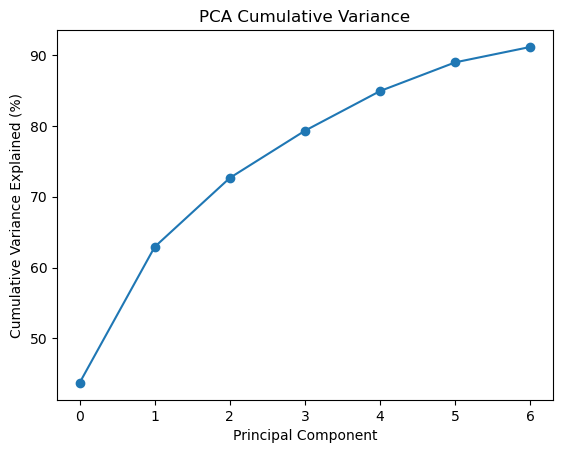

In [5]:
pca = PCA(0.90)
pca.fit(X_train_std)

X_train_pc = pca.transform(X_train_std)
X_test_pc = pca.transform(X_test_std)

print('Number of original features:', X_train.shape[1])
print('Number of PCA features:', X_train_pc.shape[1])
print('Explained variance:', pca.explained_variance_ratio_.sum())

var_expln = np.round(pca.explained_variance_ratio_ * 100, decimals=3)
cumulative_var = np.cumsum(var_expln)
plt.plot(cumulative_var, 'o-')
plt.xlabel('Principal Component')
plt.ylabel('Cumulative Variance Explained (%)')
plt.title('PCA Cumulative Variance')
plt.show()

## 5. Run Day 1/Day 2 Models Using PCA Output

Here I use Logistic Regression and SVC, which were covered in class.

In [6]:
# 使用 PCA 特征训练 Logistic Regression
pca_logreg = LogisticRegression(C=0.01, max_iter=1000)
pca_logreg.fit(X_train_pc, y_train)
pca_lr_pred = pca_logreg.predict(X_test_pc)

print('PCA + LogReg Training set score:', pca_logreg.score(X_train_pc, y_train))
print(' Test set score:', pca_logreg.score(X_test_pc, y_test))

# 使用 PCA 特征训练 SVC
pca_svc = SVC(kernel='rbf', gamma=0.1, C=1)
pca_svc.fit(X_train_pc, y_train)
pca_svc_pred = pca_svc.predict(X_test_pc)

print('PCA + SVC Test set score:', pca_svc.score(X_test_pc, y_test))

PCA + LogReg Training set score: 0.9522613065326633
 Test set score: 0.9415204678362573
PCA + SVC Test set score: 0.9649122807017544


## 6. Run LDA on the Cancer Dataset

This is a binary classification problem, so LDA can produce at most one discriminant component. Here, LDA is used for both dimensionality reduction and classification.

Number of LDA components: 1
LDA Training set score: 0.964824120603015
 Test set score: 0.9766081871345029
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       107
           1       1.00      0.94      0.97        64

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



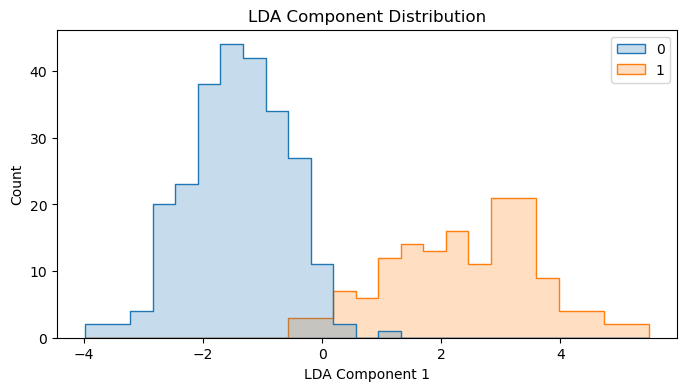

In [7]:
lda = LDA()
X_train_lda = lda.fit_transform(X_train_std, y_train)
X_test_lda = lda.transform(X_test_std)

lda_pred = lda.predict(X_test_std)
print('Number of LDA components:', X_train_lda.shape[1])
print('LDA Training set score:', lda.score(X_train_std, y_train))
print(' Test set score:', lda.score(X_test_std, y_test))
print(classification_report(y_test, lda_pred))

plt.figure(figsize=(8, 4))
sns.histplot(x=X_train_lda[:, 0], hue=y_train.to_numpy(), bins=25, element='step')
plt.title('LDA Component Distribution')
plt.xlabel('LDA Component 1')
plt.show()

## 7. Feature Selection Using ANOVA

Following the Feature Selection example, I select 13 features and then use Logistic Regression for prediction.

In [8]:
f = 13
anova = SelectKBest(score_func=f_classif, k=f).fit(X_train_std, y_train)
selected_features = X_train.columns[anova.get_support()]
print('Selected features:')
print(list(selected_features))

X_train_selected = anova.transform(X_train_std)
X_test_selected = anova.transform(X_test_std)

fs_logreg = LogisticRegression(C=0.01, max_iter=1000)
fs_logreg.fit(X_train_selected, y_train)
fs_pred = fs_logreg.predict(X_test_selected)
print('Feature Selection + LogReg Training set score:', fs_logreg.score(X_train_selected, y_train))
print(' Test set score:', fs_logreg.score(X_test_selected, y_test))

Selected features:
['radius_mean', 'perimeter_mean', 'area_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'radius_se', 'radius_worst', 'perimeter_worst', 'area_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst']
Feature Selection + LogReg Training set score: 0.9346733668341709
 Test set score: 0.9239766081871345


## 8. Compare the Performance of Different Methods

The methods below are compared using test-set Accuracy, Precision, Recall, and F1. Since malignant tumours (M) are encoded as 1, I pay particular attention to Recall: the proportion of actual malignant cases correctly identified by the model.

In [9]:
predictions = {
    'Original + LogReg': baseline_pred,
    'PCA + LogReg': pca_lr_pred,
    'PCA + SVC': pca_svc_pred,
    'LDA': lda_pred,
    'Feature Selection + LogReg': fs_pred
}

results = pd.DataFrame({
    'Method': list(predictions.keys()),
    'Accuracy': [accuracy_score(y_test, prediction) for prediction in predictions.values()],
    'Precision': [precision_score(y_test, prediction) for prediction in predictions.values()],
    'Recall': [recall_score(y_test, prediction) for prediction in predictions.values()],
    'F1': [f1_score(y_test, prediction) for prediction in predictions.values()]
})
results = results.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

best_model = results.iloc[0]
print(
    f"Best test-set method: {best_model['Method']} | "
    f"Accuracy={best_model['Accuracy']:.3f}, "
    f"F1={best_model['F1']:.3f}"
)

                    Method  Accuracy  Precision   Recall       F1
                       LDA  0.976608   1.000000 0.937500 0.967742
                 PCA + SVC  0.964912   0.983333 0.921875 0.951613
         Original + LogReg  0.947368   1.000000 0.859375 0.924370
              PCA + LogReg  0.941520   1.000000 0.843750 0.915254
Feature Selection + LogReg  0.923977   1.000000 0.796875 0.886957
Best test-set method: LDA | Accuracy=0.977, F1=0.968


In [10]:
# 查看主要模型的混淆矩阵
for name, prediction in predictions.items():
    print(name)
    print(confusion_matrix(y_test, prediction))
    print()

Original + LogReg
[[107   0]
 [  9  55]]

PCA + LogReg
[[107   0]
 [ 10  54]]

PCA + SVC
[[106   1]
 [  5  59]]

LDA
[[107   0]
 [  4  60]]

Feature Selection + LogReg
[[107   0]
 [ 13  51]]



## 9. My Summary and Reflection

In this experiment, PCA reduced 30 features to 7 principal components while retaining about 91.2% of the variance. PCA + Logistic Regression had a slightly lower Accuracy (0.942) than the original Logistic Regression (0.947), while PCA + SVC reached 0.965.

LDA achieved the highest Accuracy (0.977) and missed only 4 malignant cases, so I would prioritise LDA for this experiment.

I think PCA is useful for reducing dimensionality, but its components are not easy to interpret. LDA uses labels to find a direction that separates the classes. Although Feature Selection performed less well here, it keeps the original medical measurements and is easier to explain. In practice, I would consider Recall and interpretability as well as Accuracy.